### Note on AI assistance

Generative AI was used to assist with code development, debugging, and refinement.

In [52]:
from pathlib import Path

import numpy as np
import pandas as pd
import rasterio

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold, GroupShuffleSplit, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.base import clone
from sklearn.inspection import permutation_importance, PartialDependenceDisplay

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
)



import matplotlib.pyplot as plt

## 1 Data Loading

In [4]:

PROJECT_DIR = Path.cwd().parent
DATA_FILE = PROJECT_DIR / "data" / "processed" / "landslide_ml.csv"

df = pd.read_csv(DATA_FILE)


RASTER_DIR = PROJECT_DIR / "data" / "raw" / "Landslide Controlling Factors"

RASTERS = {
    "aspect": RASTER_DIR / "map_aspect.tif",
    "distance_river": RASTER_DIR / "map_distriv.tif",
    "distance_road": RASTER_DIR / "map_distroad.tif",
    "elevation": RASTER_DIR / "map_elev.tif",
    "lithology": RASTER_DIR / "map_geologi.tif",
    "land_use": RASTER_DIR / "map_landuse.tif",
    "plan_curvature": RASTER_DIR / "map_planc.tif",
    "profile_curvature": RASTER_DIR / "map_profc.tif",
    "slope": RASTER_DIR / "map_slope.tif",
    "spi": RASTER_DIR / "map_spi.tif",
    "twi": RASTER_DIR / "map_twi.tif",
}


In [ ]:
# Inspect the dataset structure and first rows
df.info()
display(df.head())

<class 'pandas.DataFrame'>
RangeIndex: 1486 entries, 0 to 1485
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   landslide          1486 non-null   int64  
 1   x                  1486 non-null   float64
 2   y                  1486 non-null   float64
 3   aspect             1486 non-null   float64
 4   distance_river     1486 non-null   float64
 5   distance_road      1486 non-null   float64
 6   elevation          1486 non-null   float64
 7   lithology          1485 non-null   float64
 8   land_use           1486 non-null   float64
 9   plan_curvature     1486 non-null   float64
 10  profile_curvature  1486 non-null   float64
 11  slope              1486 non-null   float64
 12  spi                1486 non-null   float64
 13  twi                1486 non-null   float64
dtypes: float64(13), int64(1)
memory usage: 162.7 KB


,landslide,x,y,aspect,distance_river,distance_road,elevation,lithology,land_use,plan_curvature,profile_curvature,slope,spi,twi
0,1,509435.847792,9.093568e+06,171.1,679.0,10.0,3.9,2.0,10.0,-0.113,-0.002,2.3,0.074,10.37
1,1,514069.366439,9.093404e+06,277.6,739.3,28.3,29.5,2.0,8.0,0.011,-0.001,21.0,0.850,4.81
2,1,514979.679513,9.094294e+06,345.1,702.1,222.0,135.2,32.0,3.0,0.006,0.000,25.5,0.330,4.84
3,1,518012.406006,9.088957e+06,356.3,376.4,557.3,198.9,32.0,6.0,-0.071,-0.005,9.6,0.642,9.49
4,1,518427.827438,9.089537e+06,250.9,70.0,493.4,155.4,32.0,6.0,0.024,-0.001,31.2,-4.206,3.88


## 2 Feature Preparation

In [6]:
#Transform Aspect in Sine und Cosine to account for its circular nature

df["aspect_sin"] = np.sin(np.deg2rad(df["aspect"]))
df["aspect_cos"] = np.cos(np.deg2rad(df["aspect"]))

In [7]:
# Separate target variable, coordinates and predictor features

#y is the variable to be predicted. In this case, ‘landslide’ (0 = no landslide, 1 = landslide)
y = df["landslide"]

coordinates = df[["x", "y"]].copy()

#Remove features that are not required for the prediction (target variable, coordinates and orientation)
X = df.drop(
    columns=[
        "landslide",
        "x",
        "y",
        "aspect",
    ]
)

In [8]:
# Define categorical and numerical features

categorical_features = [
    "lithology",
    "land_use",
]

numeric_features = [
    "distance_river",
    "distance_road",
    "elevation",
    "plan_curvature",
    "profile_curvature",
    "slope",
    "spi",
    "twi",
    "aspect_sin",
    "aspect_cos",
]

## 3 Train-Test Split

In [9]:
# Split data into training and test sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y,         # that the distribution of landslide and non-landslide cases is evenly split between the training and test data.
)

print("Training samples:", len(X_train))
print("Test samples:", len(X_test))

print("\nTraining classes:")
print(y_train.value_counts())

print("\nTest classes:")
print(y_test.value_counts())

Training samples: 1188
Test samples: 298

Training classes:
landslide
1    594
0    594
Name: count, dtype: int64

Test classes:
landslide
0    149
1    149
Name: count, dtype: int64


## 4 Preprocessing and Model Pipeline

In [10]:

#Preprocessing pipeline for categorical features



categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent"), #Here, a NAN value is replaced with the most frequent value in the column
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
            ),
        ),
    ]
)

In [11]:
# Combine categorical preprocessing and numerical features

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            categorical_transformer,
            categorical_features,
        ),
        (
            "numeric",
            "passthrough",      #Numeric features are passed on unchanged
            numeric_features,
        ),
    ]
)

In [12]:
# Combine preprocessing and Random Forest classifier

baseline_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor,
        ),
        (
            "classifier",
            RandomForestClassifier(
                random_state=42,
                n_jobs=-1,
            ),
        ),
    ]
)

## 5 Baseline Random Forest

In [61]:
# Train the baseline model

baseline_pipeline.fit(X_train, y_train);

In [17]:
# Inspect features after preprocessing

feature_names = (
    baseline_pipeline
    .named_steps["preprocessor"]
    .get_feature_names_out()
)


print(f"Number of features after preprocessing: {len(feature_names)}")
print(feature_names)

Number of features after preprocessing: 34
['categorical__lithology_2.0' 'categorical__lithology_7.0'
 'categorical__lithology_8.0' 'categorical__lithology_12.0'
 'categorical__lithology_13.0' 'categorical__lithology_16.0'
 'categorical__lithology_20.0' 'categorical__lithology_26.0'
 'categorical__lithology_27.0' 'categorical__lithology_29.0'
 'categorical__lithology_30.0' 'categorical__lithology_31.0'
 'categorical__lithology_32.0' 'categorical__land_use_1.0'
 'categorical__land_use_2.0' 'categorical__land_use_3.0'
 'categorical__land_use_4.0' 'categorical__land_use_5.0'
 'categorical__land_use_6.0' 'categorical__land_use_8.0'
 'categorical__land_use_10.0' 'categorical__land_use_11.0'
 'categorical__land_use_12.0' 'categorical__land_use_13.0'
 'numeric__distance_river' 'numeric__distance_road' 'numeric__elevation'
 'numeric__plan_curvature' 'numeric__profile_curvature' 'numeric__slope'
 'numeric__spi' 'numeric__twi' 'numeric__aspect_sin' 'numeric__aspect_cos']


In [18]:
# Predictions on the test set

y_pred = baseline_pipeline.predict(X_test)
y_prob = baseline_pipeline.predict_proba(X_test)[:, 1]

In [19]:
# Evaluate baseline model

baseline_results = {
    "Model": "Baseline RF",
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1": f1_score(y_test, y_pred),
    "ROC-AUC": roc_auc_score(y_test, y_prob),
    "PR-AUC": average_precision_score(y_test, y_prob),
}

pd.DataFrame([baseline_results])

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Baseline RF,0.704698,0.699346,0.718121,0.708609,0.762916,0.729997


In [ ]:
# Detailed classification results

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Confusion Matrix:
[[103  46]
 [ 42 107]]

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.69      0.70       149
           1       0.70      0.72      0.71       149

    accuracy                           0.70       298
   macro avg       0.70      0.70      0.70       298
weighted avg       0.70      0.70      0.70       298



## 6 Hyperparameter Tuning

In [34]:
# Define a broad hyperparameter search space

param_distributions = {
    "classifier__n_estimators": [100, 200, 300, 500],
    "classifier__max_depth": [None, 5, 10, 20, 30],
    "classifier__min_samples_split": [2, 5, 10],
    "classifier__min_samples_leaf": [1, 2, 4],
    "classifier__max_features": ["sqrt", "log2", 0.5],
}


# Define stratified 5-fold cross-validation

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42,
)

In [35]:
# Configure the randomized hyperparameter search

random_search = RandomizedSearchCV(
    estimator=baseline_pipeline,
    param_distributions=param_distributions,
    n_iter=30, #number of random combinations of hyperparameters to be tested
    scoring="roc_auc", #Score used to evaluate the quality of the combination of hyperparameters
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1,
)

In [30]:
# Run the randomized search and display the best result

random_search.fit(X_train, y_train)

print("Best CV ROC-AUC:", random_search.best_score_)
print("\nBest parameters:")

for parameter, value in random_search.best_params_.items():
    print(f"{parameter}: {value}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best CV ROC-AUC: 0.7595635662041487

Best parameters:
classifier__n_estimators: 500
classifier__min_samples_split: 5
classifier__min_samples_leaf: 2
classifier__max_features: log2
classifier__max_depth: None


In [36]:
# Refine the hyperparameter search around the RandomizedSearchCV results

param_grid = {
    "classifier__n_estimators": [300, 500, 700],
    "classifier__max_depth": [None, 20, 30],
    "classifier__min_samples_split": [3, 5, 7],
    "classifier__min_samples_leaf": [1, 2, 3],
    "classifier__max_features": ["sqrt", "log2"],
}




grid_search = GridSearchCV(
    estimator=baseline_pipeline,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1,
)

grid_search.fit(X_train, y_train)


print("Best CV ROC-AUC:", grid_search.best_score_)
print("Best parameters:")
print(grid_search.best_params_)

Fitting 5 folds for each of 162 candidates, totalling 810 fits
Best CV ROC-AUC: 0.7595781682563354
Best parameters:
{'classifier__max_depth': 20, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 500}


In [31]:
# Use the best GridSearch model for final test-set predictions

final_pipeline = grid_search.best_estimator_

y_pred_final = final_pipeline.predict(X_test)
y_prob_final = final_pipeline.predict_proba(X_test)[:, 1]


In [32]:
# Evaluate the tuned model and compare it with the baseline

final_results = {
    "Model": "Final tuned RF",
    "Accuracy": accuracy_score(y_test, y_pred_final),
    "Precision": precision_score(y_test, y_pred_final),
    "Recall": recall_score(y_test, y_pred_final),
    "F1": f1_score(y_test, y_pred_final),
    "ROC-AUC": roc_auc_score(y_test, y_prob_final),
    "PR-AUC": average_precision_score(y_test, y_prob_final),
}

results = pd.DataFrame([
    baseline_results,
    final_results,
])

results

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Baseline RF,0.704698,0.699346,0.718121,0.708609,0.762916,0.729997
1,Final tuned RF,0.677852,0.677852,0.677852,0.677852,0.769560,0.754626


In [33]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_final))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_final))

Confusion Matrix:
[[101  48]
 [ 48 101]]

Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.68      0.68       149
           1       0.68      0.68      0.68       149

    accuracy                           0.68       298
   macro avg       0.68      0.68      0.68       298
weighted avg       0.68      0.68      0.68       298



### Tuning result

Hyperparameter tuning was optimized for ROC-AUC using 5-fold stratified
cross-validation on the training set. The tuned model achieved a slightly
higher ROC-AUC and PR-AUC on the held-out test set, while accuracy,
precision, recall, and F1-score decreased compared with the baseline model.

## 7 Spatial Split Evaluation

In [37]:
# Create 5 km spatial blocks based on point coordinates

block_size = 5000  # metres

spatial_groups = (
    ((coordinates["x"] - coordinates["x"].min()) // block_size).astype(int).astype(str)
    + "_"
    + ((coordinates["y"] - coordinates["y"].min()) // block_size).astype(int).astype(str)
)

print("Number of spatial blocks:", spatial_groups.nunique())
print("\nPoints per block:")
print(spatial_groups.value_counts().sort_index())

Number of spatial blocks: 73

Points per block:
0_1      9
0_2     16
0_3      9
0_4      2
10_0    15
        ..
9_3     20
9_4     17
9_5     15
9_6     16
9_7      1
Name: count, Length: 73, dtype: int64


In [38]:
# Split complete spatial blocks into training and test sets

spatial_split = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42,
)

train_idx, test_idx = next(
    spatial_split.split(
        X,
        y,
        groups=spatial_groups,
    )
)


X_train_spatial = X.iloc[train_idx]
X_test_spatial = X.iloc[test_idx]

y_train_spatial = y.iloc[train_idx]
y_test_spatial = y.iloc[test_idx]



print("Spatial training samples:", len(X_train_spatial))
print("Spatial test samples:", len(X_test_spatial))

print("\nTraining class distribution:")
print(y_train_spatial.value_counts())
print(y_train_spatial.value_counts(normalize=True))

print("\nTest class distribution:")
print(y_test_spatial.value_counts())
print(y_test_spatial.value_counts(normalize=True))

print("\nTraining blocks:", spatial_groups.iloc[train_idx].nunique())
print("Test blocks:", spatial_groups.iloc[test_idx].nunique())

Spatial training samples: 1259
Spatial test samples: 227

Training class distribution:
landslide
1    660
0    599
Name: count, dtype: int64
landslide
1    0.524226
0    0.475774
Name: proportion, dtype: float64

Test class distribution:
landslide
0    144
1     83
Name: count, dtype: int64
landslide
0    0.634361
1    0.365639
Name: proportion, dtype: float64

Training blocks: 58
Test blocks: 15


In [39]:
# Train the tuned RF configuration on the spatial split
spatial_pipeline = clone(final_pipeline)  #Takes the pipeline structure and hyperparameters, but not the model’s pre-trained state (fit)

spatial_pipeline.fit(
    X_train_spatial,
    y_train_spatial,
)

y_pred_spatial = spatial_pipeline.predict(X_test_spatial)
y_prob_spatial = spatial_pipeline.predict_proba(X_test_spatial)[:, 1]

In [40]:
# Evaluate the model on the spatial test set

spatial_results = {
    "Model": "Tuned RF - Spatial Split",
    "Accuracy": accuracy_score(y_test_spatial, y_pred_spatial),
    "Precision": precision_score(y_test_spatial, y_pred_spatial),
    "Recall": recall_score(y_test_spatial, y_pred_spatial),
    "F1": f1_score(y_test_spatial, y_pred_spatial),
    "ROC-AUC": roc_auc_score(y_test_spatial, y_prob_spatial),
    "PR-AUC": average_precision_score(y_test_spatial, y_prob_spatial),
}

pd.DataFrame([spatial_results])

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Tuned RF - Spatial Split,0.682819,0.563218,0.590361,0.576471,0.742637,0.586679


In [41]:
# Detailed classification results

print("Confusion Matrix:")
print(confusion_matrix(y_test_spatial, y_pred_spatial))

print("\nClassification Report:")
print(classification_report(y_test_spatial, y_pred_spatial))

Confusion Matrix:
[[106  38]
 [ 34  49]]

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.74      0.75       144
           1       0.56      0.59      0.58        83

    accuracy                           0.68       227
   macro avg       0.66      0.66      0.66       227
weighted avg       0.69      0.68      0.68       227



In [43]:
# Compare random and spatial split results
comparison_results = pd.DataFrame([
    final_results,
    spatial_results,
])

comparison_results["Model"] = ["Random", "Spatial"]
comparison_results = comparison_results.rename(columns={"Model": "Split"})

comparison_results.round(3)

,Split,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Random,0.678,0.678,0.678,0.678,0.770,0.755
1,Spatial,0.683,0.563,0.590,0.576,0.743,0.587


### Repeated Random and Spatial Splits

In [45]:
# Repeated evaluation of random and spatial train/test splits

n_repeats = 30

random_split_results = []
spatial_split_results = []

for seed in range(n_repeats):

    
    # Random split
    X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=seed,
        stratify=y,
    )

    model_r = clone(final_pipeline)
    model_r.fit(X_train_r, y_train_r)

    y_pred_r = model_r.predict(X_test_r)
    y_prob_r = model_r.predict_proba(X_test_r)[:, 1]

    random_split_results.append({
        "Seed": seed,
        "Accuracy": accuracy_score(y_test_r, y_pred_r),
        "Precision": precision_score(y_test_r, y_pred_r),
        "Recall": recall_score(y_test_r, y_pred_r),
        "F1": f1_score(y_test_r, y_pred_r),
        "ROC-AUC": roc_auc_score(y_test_r, y_prob_r),
        "PR-AUC": average_precision_score(y_test_r, y_prob_r),
    })

    
    
    # Spatial split
    gss = GroupShuffleSplit(
        n_splits=1,
        test_size=0.20,
        random_state=seed,
    )

    train_idx, test_idx = next(
        gss.split(X, y, groups=spatial_groups)
    )

    X_train_s = X.iloc[train_idx]
    X_test_s = X.iloc[test_idx]
    y_train_s = y.iloc[train_idx]
    y_test_s = y.iloc[test_idx]

    model_s = clone(final_pipeline)
    model_s.fit(X_train_s, y_train_s)

    y_pred_s = model_s.predict(X_test_s)
    y_prob_s = model_s.predict_proba(X_test_s)[:, 1]

    spatial_split_results.append({
        "Seed": seed,
        "Accuracy": accuracy_score(y_test_s, y_pred_s),
        "Precision": precision_score(y_test_s, y_pred_s),
        "Recall": recall_score(y_test_s, y_pred_s),
        "F1": f1_score(y_test_s, y_pred_s),
        "ROC-AUC": roc_auc_score(y_test_s, y_prob_s),
        "PR-AUC": average_precision_score(y_test_s, y_prob_s),
    })


random_repeated = pd.DataFrame(random_split_results)
spatial_repeated = pd.DataFrame(spatial_split_results)

In [46]:
# Summarize performance across repeated splits

metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC-AUC",
    "PR-AUC",
]

repeated_summary = pd.DataFrame({
    "Random Mean": random_repeated[metrics].mean(),
    "Random SD": random_repeated[metrics].std(),
    "Spatial Mean": spatial_repeated[metrics].mean(),
    "Spatial SD": spatial_repeated[metrics].std(),
})

repeated_summary.round(3)

,Random Mean,Random SD,Spatial Mean,Spatial SD
Accuracy,0.686,0.027,0.672,0.040
Precision,0.679,0.030,0.667,0.069
Recall,0.708,0.042,0.674,0.072
F1,0.693,0.028,0.668,0.057
ROC-AUC,0.757,0.022,0.740,0.046
PR-AUC,0.736,0.023,0.713,0.062


The table shows that random splits produce slightly better and more stable results; spatially separated tests result in slightly lower and significantly more variable performance. This suggests that a purely random split may present the spatial generalisation ability in a somewhat optimistic light.

##  8. Permutation Feature Importance and Partial Dependence

In [47]:
# Calculate permutation feature importance on the test set

perm_importance = permutation_importance(
    final_pipeline,
    X_test,
    y_test,
    scoring="roc_auc",
    n_repeats=30,
    random_state=42,
    n_jobs=-1,
)


importance_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance_mean": perm_importance.importances_mean,
    "Importance_std": perm_importance.importances_std,
})

importance_df = importance_df.sort_values(
    "Importance_mean",
    ascending=False
)

importance_df

,Feature,Importance_mean,Importance_std
7,slope,0.045984,0.015069
10,aspect_sin,0.032524,0.010273
3,lithology,0.024781,0.007897
4,land_use,0.013267,0.003785
8,spi,0.011024,0.007253
11,aspect_cos,0.008839,0.005743
2,elevation,0.008435,0.003838
6,profile_curvature,0.006009,0.002513
1,distance_road,0.005576,0.002882
9,twi,0.005189,0.005708


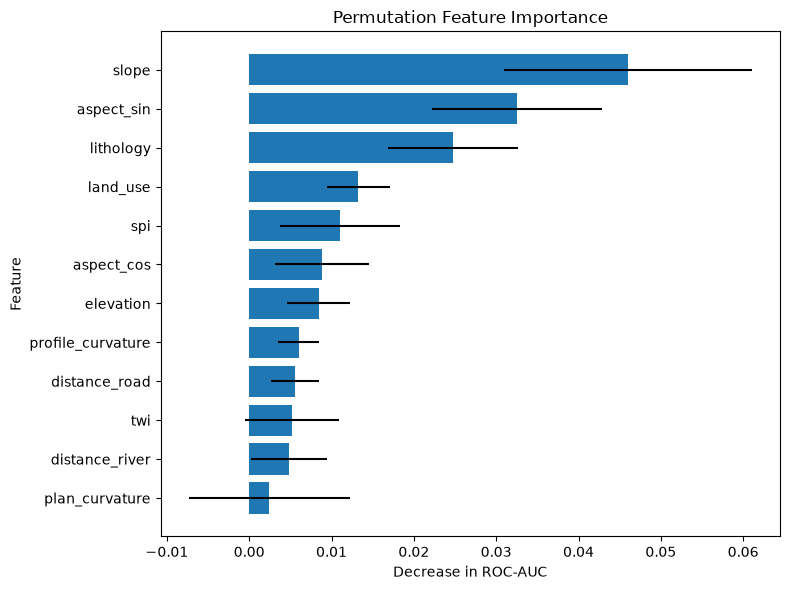

In [49]:
# Plot permutation feature importance


plot_df = importance_df.sort_values("Importance_mean")

plt.figure(figsize=(8, 6))

plt.barh(
    plot_df["Feature"],
    plot_df["Importance_mean"],
    xerr=plot_df["Importance_std"],
)

plt.xlabel("Decrease in ROC-AUC")
plt.ylabel("Feature")
plt.title("Permutation Feature Importance")

plt.tight_layout()
plt.show()

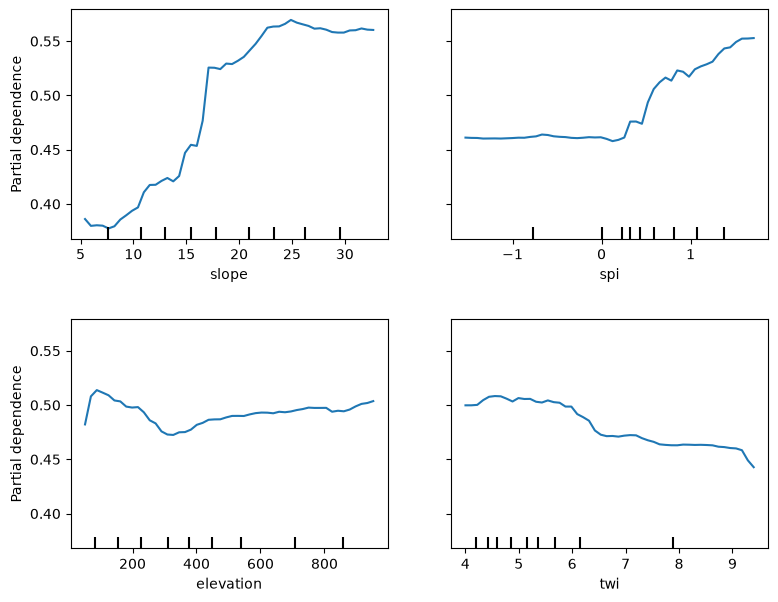

In [60]:
# Plot partial dependence for selected numerical features

pdp_features = [
    "slope",
    "spi",
    "elevation",
    "twi",
]


fig, ax = plt.subplots(2, 2, figsize=(9, 7))

PartialDependenceDisplay.from_estimator(
    final_pipeline,
    X_test,
    features=pdp_features,
    kind="average",
    grid_resolution=50,
      ax=ax,
)


plt.subplots_adjust(hspace=0.35, wspace=0.20)
plt.show()

## 9. Landslide Susceptibility Mapping

In [62]:
# Train the final model on all available point data

map_model = clone(final_pipeline)

map_model.fit(X, y);

In [ ]:
# Load predictor rasters and identify pixels with valid data

raster_arrays = {}
valid_mask = None

for feature_name, raster_path in RASTERS.items():
    with rasterio.open(raster_path) as src:
        data = src.read(1)

        # Identify valid pixels in the current raster
        if src.nodata is not None:
            raster_valid = data != src.nodata
        else:
            raster_valid = np.ones(data.shape, dtype=bool)

        raster_arrays[feature_name] = data

        if valid_mask is None:
            valid_mask = raster_valid
        else:
            valid_mask &= raster_valid

print("Raster shape:", valid_mask.shape)
print("Valid pixels:", valid_mask.sum())
print("Invalid pixels:", (~valid_mask).sum())

Raster shape: (4051, 5815)
Valid pixels: 14129750
Invalid pixels: 9426815


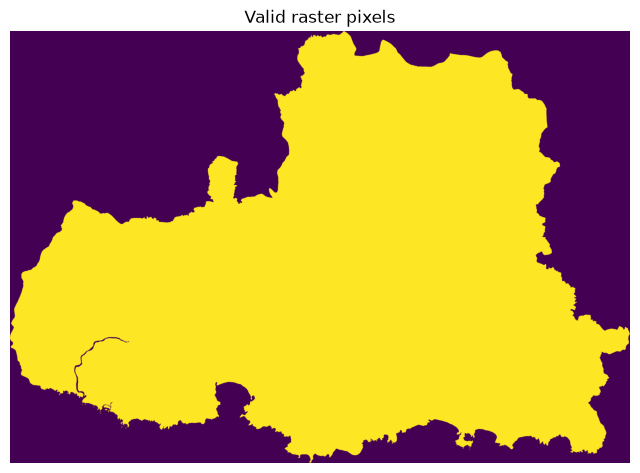

In [54]:
# Visualize the spatial extent of valid raster data

plt.figure(figsize=(8, 6))
plt.imshow(valid_mask)
plt.title("Valid raster pixels")
plt.axis("off")
plt.show()

The visualization shows that the large number of invalid pixels mainly represents areas outside the study area, while the study area itself is covered by valid predictor data.

In [55]:
# Predict landslide susceptibility for all valid raster pixels in chunks

chunk_size = 500_000

valid_indices = np.flatnonzero(valid_mask.ravel())

susceptibility = np.full(
    valid_mask.shape,
    -9999.0,
    dtype=np.float32
)

susceptibility_flat = susceptibility.ravel()

for start in range(0, len(valid_indices), chunk_size):

    end = min(start + chunk_size, len(valid_indices))
    idx = valid_indices[start:end]

    aspect_deg = raster_arrays["aspect"].ravel()[idx]
    aspect_rad = np.deg2rad(aspect_deg)

    X_map = pd.DataFrame({
        "distance_river": raster_arrays["distance_river"].ravel()[idx],
        "distance_road": raster_arrays["distance_road"].ravel()[idx],
        "elevation": raster_arrays["elevation"].ravel()[idx],
        "lithology": raster_arrays["lithology"].ravel()[idx],
        "land_use": raster_arrays["land_use"].ravel()[idx],
        "plan_curvature": raster_arrays["plan_curvature"].ravel()[idx],
        "profile_curvature": raster_arrays["profile_curvature"].ravel()[idx],
        "slope": raster_arrays["slope"].ravel()[idx],
        "spi": raster_arrays["spi"].ravel()[idx],
        "twi": raster_arrays["twi"].ravel()[idx],
        "aspect_sin": np.sin(aspect_rad),
        "aspect_cos": np.cos(aspect_rad),
    })

    probabilities = map_model.predict_proba(X_map)[:, 1]

    susceptibility_flat[idx] = probabilities

    print(f"Processed {end:,} / {len(valid_indices):,} pixels")

Processed 500,000 / 14,129,750 pixels
Processed 1,000,000 / 14,129,750 pixels
Processed 1,500,000 / 14,129,750 pixels
Processed 2,000,000 / 14,129,750 pixels
Processed 2,500,000 / 14,129,750 pixels
Processed 3,000,000 / 14,129,750 pixels
Processed 3,500,000 / 14,129,750 pixels
Processed 4,000,000 / 14,129,750 pixels
Processed 4,500,000 / 14,129,750 pixels
Processed 5,000,000 / 14,129,750 pixels
Processed 5,500,000 / 14,129,750 pixels
Processed 6,000,000 / 14,129,750 pixels
Processed 6,500,000 / 14,129,750 pixels
Processed 7,000,000 / 14,129,750 pixels
Processed 7,500,000 / 14,129,750 pixels
Processed 8,000,000 / 14,129,750 pixels
Processed 8,500,000 / 14,129,750 pixels
Processed 9,000,000 / 14,129,750 pixels
Processed 9,500,000 / 14,129,750 pixels
Processed 10,000,000 / 14,129,750 pixels
Processed 10,500,000 / 14,129,750 pixels
Processed 11,000,000 / 14,129,750 pixels
Processed 11,500,000 / 14,129,750 pixels
Processed 12,000,000 / 14,129,750 pixels
Processed 12,500,000 / 14,129,750 pix

Min: 0.010369129
Max: 0.9507062
Mean: 0.41150326
NoData pixels: 9426815


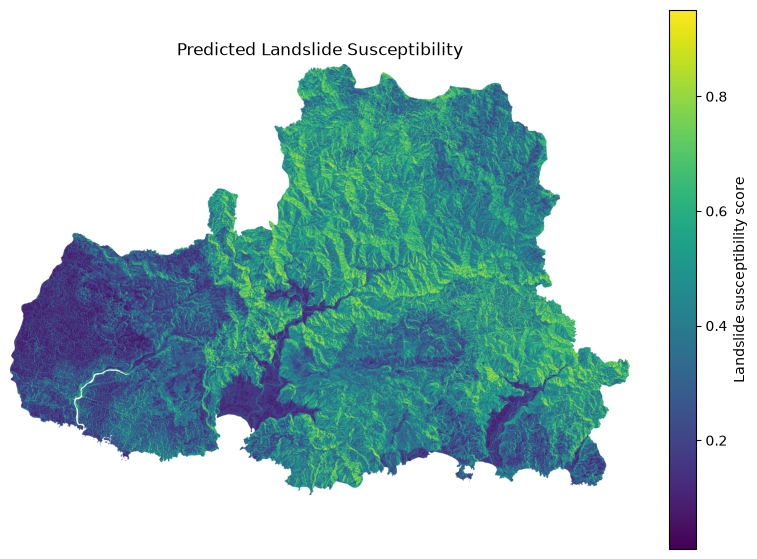

In [56]:
# Inspect and visualize the predicted susceptibility values

valid_values = susceptibility[valid_mask]

print("Min:", valid_values.min())
print("Max:", valid_values.max())
print("Mean:", valid_values.mean())
print("NoData pixels:", np.sum(susceptibility == -9999.0))


plt.figure(figsize=(10, 7))
plt.imshow(
    np.where(valid_mask, susceptibility, np.nan)
)
plt.colorbar(label="Landslide susceptibility score")
plt.title("Predicted Landslide Susceptibility")
plt.axis("off")
plt.show()

In [57]:
# Save the susceptibility map as a GeoTIFF

OUTPUT_RASTER = (
    PROJECT_DIR
    / "data"
    / "processed"
    / "landslide_susceptibility.tif"
)

with rasterio.open(RASTERS["aspect"]) as src:
    profile = src.profile.copy()

profile.update(
    dtype="float32",
    count=1,
    nodata=-9999.0,
)

with rasterio.open(OUTPUT_RASTER, "w", **profile) as dst:
    dst.write(susceptibility, 1)

print(f"Saved susceptibility raster to:\n{OUTPUT_RASTER}")

Saved susceptibility raster to:
c:\Users\milan\OneDrive\Dokumente\Studium\Master\2. Semester\ML in Geo\Abschluss_Projekt\landslide-susceptibility\data\processed\landslide_susceptibility.tif
